Copyright (c) 2019 [Sebastian Raschka](sebastianraschka.com)

https://github.com/rasbt/python-machine-learning-book-3rd-edition

[MIT License](https://github.com/rasbt/python-machine-learning-book-3rd-edition/blob/master/LICENSE.txt)

# Python Machine Learning - Code Examples

# Chapter 2 - Training Machine Learning Algorithms for Classification

Note that the optional watermark extension is a small IPython notebook plugin that I developed to make the code reproducible. You can just skip the following line(s).

In [31]:
%load_ext watermark
%watermark -a "Sebastian Raschka" -u -d -p numpy,pandas,matplotlib

%matplotlib inline

The watermark extension is already loaded. To reload it, use:
  %reload_ext watermark
Author: Sebastian Raschka

Last updated: 2025-05-13

numpy     : 2.2.5
pandas    : 2.2.3
matplotlib: 3.10.1



*The use of `watermark` is optional. You can install this Jupyter extension via*  

    conda install watermark -c conda-forge  

or  

    pip install watermark   

*For more information, please see: https://github.com/rasbt/watermark.*

### Overview


- [Artificial neurons – a brief glimpse into the early history of machine learning](#Artificial-neurons-a-brief-glimpse-into-the-early-history-of-machine-learning)
    - [The formal definition of an artificial neuron](#The-formal-definition-of-an-artificial-neuron)
    - [The perceptron learning rule](#The-perceptron-learning-rule)
- [Implementing a perceptron learning algorithm in Python](#Implementing-a-perceptron-learning-algorithm-in-Python)
    - [An object-oriented perceptron API](#An-object-oriented-perceptron-API)
    - [Training a perceptron model on the Iris dataset](#Training-a-perceptron-model-on-the-Iris-dataset)
- [Adaptive linear neurons and the convergence of learning](#Adaptive-linear-neurons-and-the-convergence-of-learning)
    - [Minimizing cost functions with gradient descent](#Minimizing-cost-functions-with-gradient-descent)
    - [Implementing an Adaptive Linear Neuron in Python](#Implementing-an-Adaptive-Linear-Neuron-in-Python)
    - [Improving gradient descent through feature scaling](#Improving-gradient-descent-through-feature-scaling)
    - [Large scale machine learning and stochastic gradient descent](#Large-scale-machine-learning-and-stochastic-gradient-descent)
- [Summary](#Summary)

<br>
<br>

In [1]:
from IPython.display import Image
from IPython.display import HTML

# Artificial neurons - a brief glimpse into the early history of machine learning

In [2]:
# Image(filename='./images/02_01.png', width=300)
HTML('<img src="./images/02_01.png" style="width: 50%;" />')

## The formal definition of an artificial neuron

In [3]:
# Image(filename='./images/02_02.png', width=500) 
HTML('<img src="./images/02_02.png" style="width: 50%;" />')

## The perceptron learning rule

In [4]:
# Image(filename='./images/02_03.png', width=600) 
HTML('<img src="./images/02_03.png" style="width: 50%;" />')

In [5]:
# Image(filename='./images/02_04.png', width=600) 
HTML('<img src="./images/02_04.png" style="width: 50%;" />')

<br>
<br>

# Implementing a perceptron learning algorithm in Python

## An object-oriented perceptron API

In [6]:
import numpy as np


class Perceptron(object):
    """Perceptron classifier.

    Parameters
    ------------
    eta : float
      Learning rate (between 0.0 and 1.0)
    n_iter : int
      Passes over the training dataset.
    random_state : int
      Random number generator seed for random weight
      initialization.

    Attributes
    -----------
    w_ : 1d-array
      Weights after fitting.
    errors_ : list
      Number of misclassifications (updates) in each epoch.

    """
    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        """Fit training data.

        Parameters
        ----------
        X : {array-like}, shape = [n_examples, n_features]
          Training vectors, where n_examples is the number of examples and
          n_features is the number of features.
        y : array-like, shape = [n_examples]
          Target values.

        Returns
        -------
        self : object

        """
        rgen = np.random.RandomState(self.random_state)
        # initialize weights, here normal distribution with mean 0 and stddev 0.01
        # size=1 + X.shape[1]: one weight per feature plus one bias weight(w_[0])
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=1 + X.shape[1])
        self.errors_ = []

        for _ in range(self.n_iter):
            # Set the errors to 0 in the beginning of each epoch
            errors = 0
            for xi, target in zip(X, y):
                # Calculate the delta (update) for the weights
                # target - self.predict(xi) is the delta
                # self.predict(xi) is the output of the perceptron
                # xi is the input vector
                # This shoudl return 1 or -1
                # The perceptron learning rule is:
                # w(t+1) = w(t) + eta * (target - output) * x
                # where w(t) is the weight vector at time t, eta is the learning rate,
                update = self.eta * (target - self.predict(xi))

                # Update the feature weights
                self.w_[1:] += update * xi
                # Update the bias weight, because it is a constant(1), the update is
                # just the learning rate times the delta
                self.w_[0] += update
                errors += int(update != 0.0)
            self.errors_.append(errors)
        return self

    def net_input(self, X):
        """Calculate net input"""
        
        return np.dot(X, self.w_[1:]) + self.w_[0]

    def predict(self, X):
        """Return class label after unit step"""
        # The perceptron activation function is a step function
        # If the net input is greater than or equal to 0, return 1
        return np.where(self.net_input(X) >= 0.0, 1, -1)

Let’s break it down:

```python
np.dot(X, self.w_[1:]) + self.w_[0]
```

1. **`self.w_[1:]`**

   * This slices off the first element of the weight vector, leaving just the weights for your features.
   * If you have $m$ features, `self.w_[1:]` is an array of length $m$:

     $$
       [\,w_1, w_2, \dots, w_m\,].
     $$

2. **`np.dot(X, self.w_[1:])`**

   * **Dot product** between:

     * `X`, which here is either

       * a single example vector of shape `(m,)`, or
       * a matrix of shape `(n_samples, m)`, if you pass multiple examples,
     * and the weight vector `self.w_[1:]` of shape `(m,)`.
   * This computes the weighted sum of your features:

     $$
       w_1\,x_1 \;+\; w_2\,x_2 \;+\; \dots \;+\; w_m\,x_m
     $$

     for each example.
   * **Result:**

     * If `X` is one vector, you get a single scalar $z$.
     * If `X` is a 2D array of $n$ examples, you get a length-$n$ array of net inputs.

3. **`+ self.w_[0]`**

   * `self.w_[0]` is the **bias** term (formerly $-\theta$).

   * By adding it, you shift the entire net input:

     $$
     \begin{aligned}
       z 
       &= \bigl(w_1\,x_1 + w_2\,x_2 + \dots + w_m\,x_m\bigr) \;+\; b \\[6pt]
       &= \mathbf{w}^\top \mathbf{x} \;+\; b
     \end{aligned}
     $$

   * This lets your decision boundary move away from the origin.

---

**In plain English:**

> Take the weighted sum of your features (`np.dot(...)`), then add the bias (`self.w_[0]`). The result is the perceptron’s “net input” $z$, which you then feed into the step function to get your final prediction.


In [7]:
# Why we need to initialize the weights to small random numbers?
v1 = np.array([1, 2, 3])
v2 = 0.5 * v1

# Their angle is 0 the same and the cosine similarity is 1 because v2 is a scaled copy of v1
# This calculates the angle between two vectors
np.arccos(v1.dot(v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)))

np.float64(0.0)


4.  **Crucial Point: Why Not Initialize Weights to Zero?**
    * The text strongly emphasizes that weights should **not** be initialized to zero.
    * If all weights start at zero, the learning rate ($\eta$, or `eta`) only influences the *magnitude (scale or length)* of the weight vector during updates, but it **does not affect the direction** of the weight vector.
    * The **direction** of the weight vector is critical because it defines the orientation of the decision boundary that separates classes.
    * **Analogy with Vectors:**
        * Imagine a vector $v1 = [1, 2, 3]$.
        * If you create another vector $v2 = 0.5 \times v1 = [0.5, 1, 1.5]$, $v2$ is shorter than $v1$, but it points in the exact same direction. The angle between them is 0.
        * Similarly, if all weights are zero, the initial "direction" of any update will be solely determined by the input features of the first misclassified example. The learning rate would only scale this. Subsequent updates might also be constrained in direction.
    * By initializing weights to small *random* non-zero values, the learning algorithm can explore different directions for the decision boundary from the outset, leading to a more effective learning process.

5.  **Arbitrariness of Specific Distribution Parameters**:
    * The choice of a normal distribution and a specific standard deviation (like 0.01) is somewhat arbitrary.
    * The primary goal is to initialize the weights to **small, random, non-zero values**. This avoids the symmetry and directional problems associated with zero-initialization and allows the learning algorithm to effectively adjust the weights (and thus the decision boundary) during training.

In summary, the passage highlights that proper weight initialization in the perceptron involves creating a weight vector that includes a bias term, populating it with small random numbers (not zeros) drawn from a distribution like the normal distribution, and understanding that this non-zero random start is essential for the learning rate to effectively guide the direction of the weight vector during training.

<br>
<br>

## Training a perceptron model on the Iris dataset

...

### Reading-in the Iris data

In [8]:
import os
import pandas as pd


s = 'https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
print('URL:', s)

df = pd.read_csv(s,
                 header=None,
                 encoding='utf-8')

df.tail()

URL: https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data


,0,1,2,3,4
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


<hr>

### Note:


You can find a copy of the Iris dataset (and all other datasets used in this book) in the code bundle of this book, which you can use if you are working offline or the UCI server at https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data is temporarily unavailable. For instance, to load the Iris dataset from a local directory, you can replace the line 

    df = pd.read_csv('https://archive.ics.uci.edu/ml/'
        'machine-learning-databases/iris/iris.data', header=None)
 
by
 
    df = pd.read_csv('your/local/path/to/iris.data', header=None)


In [9]:
df = pd.read_csv('iris.data', header=None, encoding='utf-8')
df.tail()

,0,1,2,3,4
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


In [10]:
# There are 2 classes of iris flowers in the first 100 samples
df[4].head(100).unique()

array(['Iris-setosa', 'Iris-versicolor'], dtype=object)

<hr>

<br>
<br>

### Plotting the Iris data

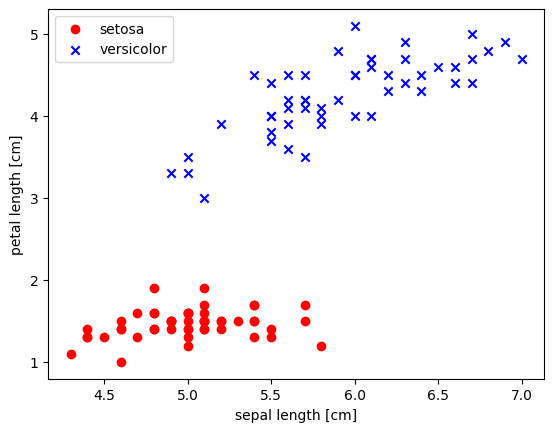

In [11]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# select setosa and versicolor
y = df.iloc[0:100, 4].values

# convert class labels to integers
# The perceptron only works with binary classification
y = np.where(y == 'Iris-setosa', -1, 1)

# extract sepal length and petal length
X = df.iloc[0:100, [0, 2]].values

# plot data
plt.scatter(X[:50, 0], X[:50, 1],
            color='red', marker='o', label='setosa')
plt.scatter(X[50:100, 0], X[50:100, 1],
            color='blue', marker='x', label='versicolor')

plt.xlabel('sepal length [cm]')
plt.ylabel('petal length [cm]')
plt.legend(loc='upper left')

# plt.savefig('images/02_06.png', dpi=300)
plt.show()

<br>
<br>

### Training the perceptron model

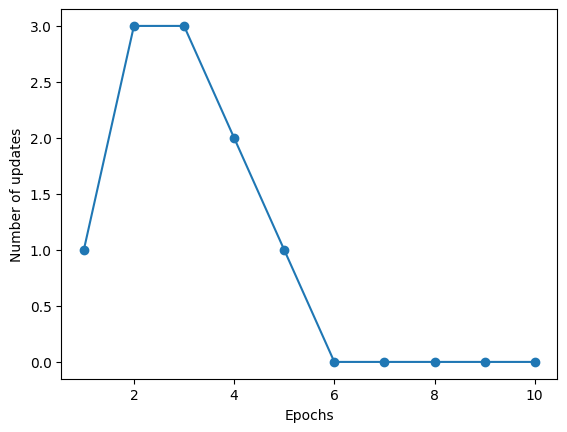

In [12]:
ppn = Perceptron(eta=0.1, n_iter=10)

ppn.fit(X, y)

plt.plot(range(1, len(ppn.errors_) + 1), ppn.errors_, marker='o')
plt.xlabel('Epochs')
plt.ylabel('Number of updates')

# plt.savefig('images/02_07.png', dpi=300)
plt.show()

<br>
<br>

### A function for plotting decision regions

In [13]:
from matplotlib.colors import ListedColormap


def plot_decision_regions(X, y, classifier, resolution=0.02):

    # setup marker generator and color map
    markers = ('s', 'x', 'o', '^', 'v')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # plot the decision surface
    # Get the min and max values of the features
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    # Create a mesh grid of the feature space, (xx1^i,xx2^i) is an element in x1 vs x2 2D mesh with these 4 values:
    # (x1_min, x1_max, x2_min, x2_max)
    # Create the x and y values of the mesh grid, xx1 and xx2 are the x and y coordinates of the mesh grid
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    
    print('xx1:\n', xx1)

    # Both xx1 and xx2 are 1D arrays of the same shape, so we can use them to create a 2xlen(xx1) array
    # np.vstack((xx1.ravel(), xx2.ravel())).T would be more explicit, this would create a 2D array of shape (len(xx1), 2)
    # This shape is (len(xx1), 2) is how we trained the perceptron, and now we can use it to predict the class labels
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    # plot class examples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], 
                    y=X[y == cl, 1],
                    alpha=0.8, 
                    c=colors[idx],
                    marker=markers[idx], 
                    label=cl, 
                    edgecolor='black')

xx1:
 [[3.3  3.32 3.34 ... 7.94 7.96 7.98]
 [3.3  3.32 3.34 ... 7.94 7.96 7.98]
 [3.3  3.32 3.34 ... 7.94 7.96 7.98]
 ...
 [3.3  3.32 3.34 ... 7.94 7.96 7.98]
 [3.3  3.32 3.34 ... 7.94 7.96 7.98]
 [3.3  3.32 3.34 ... 7.94 7.96 7.98]]


/tmp/ipykernel_232517/1201251622.py:35: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],


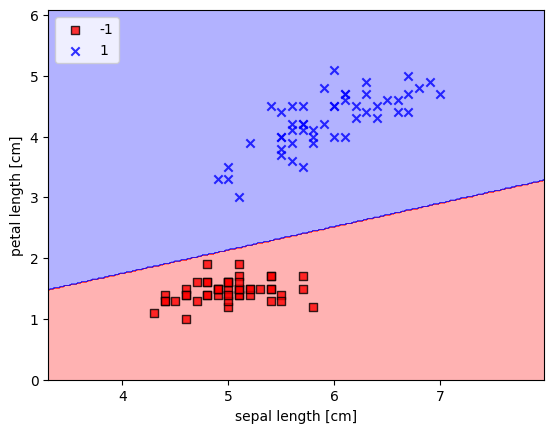

In [14]:
plot_decision_regions(X, y, classifier=ppn)
plt.xlabel('sepal length [cm]')
plt.ylabel('petal length [cm]')
plt.legend(loc='upper left')


# plt.savefig('images/02_08.png', dpi=300)
plt.show()

<br>
<br>

# Adaptive linear neurons and the convergence of learning

...

## Minimizing cost functions with gradient descent

In [15]:
# Image(filename='./images/02_09.png', width=600) 
HTML('<img src="./images/02_09.png" style="width: 40%;" />')

In [16]:
# Image(filename='./images/02_10.png', width=500) 
HTML('<img src="./images/02_10.png" style="width: 40%;" />')

<br>
<br>

## Implementing an adaptive linear neuron in Python

In [17]:
class AdalineGD(object):
    """ADAptive LInear NEuron classifier.

    Parameters
    ------------
    eta : float
      Learning rate (between 0.0 and 1.0)
    n_iter : int
      Passes over the training dataset.
    random_state : int
      Random number generator seed for random weight
      initialization.


    Attributes
    -----------
    w_ : 1d-array
      Weights after fitting.
    cost_ : list
      Sum-of-squares cost function value in each epoch.

    """
    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        """ Fit training data.

        Parameters
        ----------
        X : {array-like}, shape = [n_examples, n_features]
          Training vectors, where n_examples is the number of examples and
          n_features is the number of features.
        y : array-like, shape = [n_examples]
          Target values.

        Returns
        -------
        self : object

        """
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=1 + X.shape[1])
        self.cost_ = []

        for i in range(self.n_iter):
            net_input = self.net_input(X)
            # Please note that the "activation" method has no effect
            # in the code since it is simply an identity function. We
            # could write `output = self.net_input(X)` directly instead.
            # The purpose of the activation is more conceptual, i.e.,  
            # in the case of logistic regression (as we will see later), 
            # we could change it to
            # a sigmoid function to implement a logistic regression classifier.
            output = self.activation(net_input)
            errors = (y - output)
            self.w_[1:] += self.eta * X.T.dot(errors)
            self.w_[0] += self.eta * errors.sum()
            cost = (errors**2).sum() / 2.0
            self.cost_.append(cost)
        return self

    def net_input(self, X):
        # This is basically linear regression
        """Calculate net input"""
        return np.dot(X, self.w_[1:]) + self.w_[0]

    def activation(self, X):
        # activation function - just returns identical value, no relu or sigmoid. Keep it simple for linear regression
        """Compute linear activation"""
        return X

    def predict(self, X):
        #classify as 1 if activation is greater than 0, else -1
        """Return class label after unit step"""
        return np.where(self.activation(self.net_input(X)) >= 0.0, 1, -1)

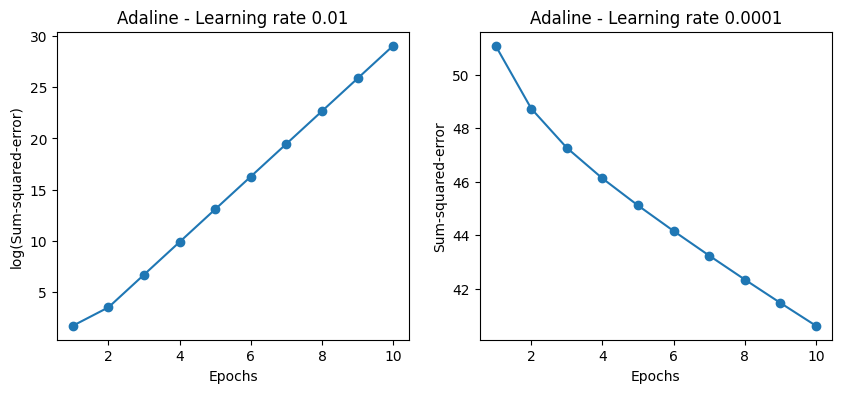

In [ ]:
# When the learning rate is too high, the cost function diverges
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

ada1 = AdalineGD(n_iter=10, eta=0.01).fit(X, y)
ax[0].plot(range(1, len(ada1.cost_) + 1), np.log10(ada1.cost_), marker='o')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('log(Sum-squared-error)')
ax[0].set_title('Adaline - Learning rate 0.01')

ada2 = AdalineGD(n_iter=10, eta=0.0001).fit(X, y)
ax[1].plot(range(1, len(ada2.cost_) + 1), ada2.cost_, marker='o')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Sum-squared-error')
ax[1].set_title('Adaline - Learning rate 0.0001')

# plt.savefig('images/02_11.png', dpi=300)
plt.show()

<br>
<br>

In [21]:
# Image(filename='./images/02_12.png', width=700) 
HTML('<img src="./images/02_12.png" style="width: 40%;" />')

<br>
<br>

## Improving gradient descent through feature scaling

In [22]:
# Image(filename='./images/02_13.png', width=700) 
HTML('<img src="./images/02_13.png" style="width: 40%;" />')

In [23]:
# standardize features
X_std = np.copy(X)
X_std[:, 0] = (X[:, 0] - X[:, 0].mean()) / X[:, 0].std()
X_std[:, 1] = (X[:, 1] - X[:, 1].mean()) / X[:, 1].std()

<ipython-input-13-0999be6beb6e>:24: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],


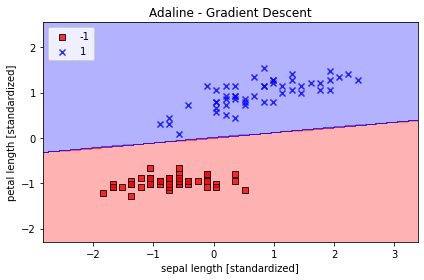

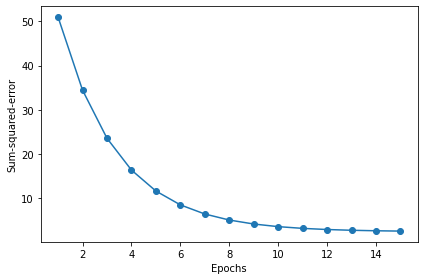

In [22]:
ada_gd = AdalineGD(n_iter=15, eta=0.01)
ada_gd.fit(X_std, y)

plot_decision_regions(X_std, y, classifier=ada_gd)
plt.title('Adaline - Gradient Descent')
plt.xlabel('sepal length [standardized]')
plt.ylabel('petal length [standardized]')
plt.legend(loc='upper left')
plt.tight_layout()
# plt.savefig('images/02_14_1.png', dpi=300)
plt.show()

plt.plot(range(1, len(ada_gd.cost_) + 1), ada_gd.cost_, marker='o')
plt.xlabel('Epochs')
plt.ylabel('Sum-squared-error')

plt.tight_layout()
# plt.savefig('images/02_14_2.png', dpi=300)
plt.show()

<br>
<br>

## Large scale machine learning and stochastic gradient descent

In [23]:
class AdalineSGD(object):
    """ADAptive LInear NEuron classifier.

    Parameters
    ------------
    eta : float
      Learning rate (between 0.0 and 1.0)
    n_iter : int
      Passes over the training dataset.
    shuffle : bool (default: True)
      Shuffles training data every epoch if True to prevent cycles.
    random_state : int
      Random number generator seed for random weight
      initialization.


    Attributes
    -----------
    w_ : 1d-array
      Weights after fitting.
    cost_ : list
      Sum-of-squares cost function value averaged over all
      training examples in each epoch.

        
    """
    def __init__(self, eta=0.01, n_iter=10, shuffle=True, random_state=None):
        self.eta = eta
        self.n_iter = n_iter
        self.w_initialized = False
        self.shuffle = shuffle
        self.random_state = random_state
        
    def fit(self, X, y):
        """ Fit training data.

        Parameters
        ----------
        X : {array-like}, shape = [n_examples, n_features]
          Training vectors, where n_examples is the number of examples and
          n_features is the number of features.
        y : array-like, shape = [n_examples]
          Target values.

        Returns
        -------
        self : object

        """
        self._initialize_weights(X.shape[1])
        self.cost_ = []
        for i in range(self.n_iter):
            if self.shuffle:
                X, y = self._shuffle(X, y)
            cost = []
            for xi, target in zip(X, y):
                cost.append(self._update_weights(xi, target))
            avg_cost = sum(cost) / len(y)
            self.cost_.append(avg_cost)
        return self

    def partial_fit(self, X, y):
        """Fit training data without reinitializing the weights"""
        if not self.w_initialized:
            self._initialize_weights(X.shape[1])
        if y.ravel().shape[0] > 1:
            for xi, target in zip(X, y):
                self._update_weights(xi, target)
        else:
            self._update_weights(X, y)
        return self

    def _shuffle(self, X, y):
        """Shuffle training data"""
        r = self.rgen.permutation(len(y))
        return X[r], y[r]
    
    def _initialize_weights(self, m):
        """Initialize weights to small random numbers"""
        self.rgen = np.random.RandomState(self.random_state)
        self.w_ = self.rgen.normal(loc=0.0, scale=0.01, size=1 + m)
        self.w_initialized = True
        
    def _update_weights(self, xi, target):
        """Apply Adaline learning rule to update the weights"""
        output = self.activation(self.net_input(xi))
        error = (target - output)
        self.w_[1:] += self.eta * xi.dot(error)
        self.w_[0] += self.eta * error
        cost = 0.5 * error**2
        return cost
    
    def net_input(self, X):
        """Calculate net input"""
        return np.dot(X, self.w_[1:]) + self.w_[0]

    def activation(self, X):
        """Compute linear activation"""
        return X

    def predict(self, X):
        """Return class label after unit step"""
        return np.where(self.activation(self.net_input(X)) >= 0.0, 1, -1)

<ipython-input-13-0999be6beb6e>:24: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],


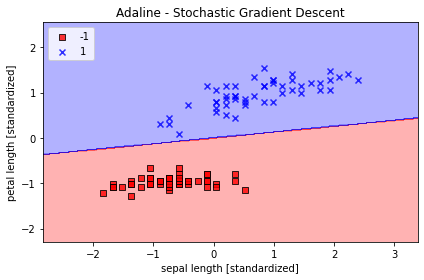

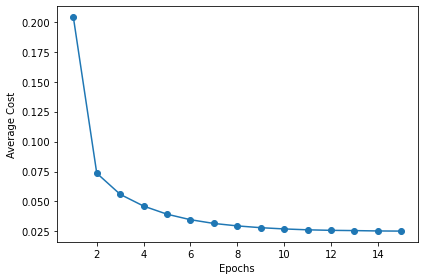

In [24]:
ada_sgd = AdalineSGD(n_iter=15, eta=0.01, random_state=1)
ada_sgd.fit(X_std, y)

plot_decision_regions(X_std, y, classifier=ada_sgd)
plt.title('Adaline - Stochastic Gradient Descent')
plt.xlabel('sepal length [standardized]')
plt.ylabel('petal length [standardized]')
plt.legend(loc='upper left')

plt.tight_layout()
# plt.savefig('images/02_15_1.png', dpi=300)
plt.show()

plt.plot(range(1, len(ada_sgd.cost_) + 1), ada_sgd.cost_, marker='o')
plt.xlabel('Epochs')
plt.ylabel('Average Cost')

plt.tight_layout()
# plt.savefig('images/02_15_2.png', dpi=300)
plt.show()

In [25]:
ada_sgd.partial_fit(X_std[0, :], y[0])

<br>
<br>

# Summary

...

--- 

Readers may ignore the following cell

In [26]:
! python ../.convert_notebook_to_script.py --input ch02.ipynb --output ch02.py

[NbConvertApp] Converting notebook ch02.ipynb to script
[NbConvertApp] Writing 16635 bytes to ch02.py
